# Packages

In [1]:
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime, timedelta, date
import math

import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_pacf

import scipy.stats as stats
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import RobustScaler, LabelEncoder, OrdinalEncoder
import gc
pd.set_option('display.max_columns', 500)
pd.set_option('display.max_rows', 500)
pd.set_option('display.float_format', lambda x: "%.4f" % x)

plt.style.use('ggplot')
sns.set_style('darkgrid')

In [2]:
# helper functions
def get_info(df):
    missing_values_train = pd.DataFrame({'Feature': df.columns,
                              'No. of Missing Values': df.isnull().sum().values,
                              '% of Missing Values': ((df.isnull().sum().values)/len(df)*100)})

    unique_values = pd.DataFrame({'Feature': df.columns,
                                'No. of Unique Values': df.nunique().values})

    feature_types = pd.DataFrame({'Feature': df.columns,
                                'DataType': df.dtypes})

    merged_df = pd.merge(missing_values_train, unique_values, on='Feature', how='left')
    merged_df = pd.merge(merged_df, feature_types, on='Feature', how='left')

    return merged_df

def reduce_memory_usage(df: pd.DataFrame, verbose=False) -> pd.DataFrame:
    start_mem = df.memory_usage(deep=True).sum() / 1024**2
    if verbose:
        print(f"Memory usage before: {start_mem:.2f} MB")
    
    for col in df.columns:
        col_type = df[col].dtype
        
        if col_type == 'float64':
            df[col] = pd.to_numeric(df[col], downcast='float')
        elif col_type == 'int64':
            df[col] = pd.to_numeric(df[col], downcast='integer')
    
    end_mem = df.memory_usage(deep=True).sum() / 1024**2
    if verbose:
        print(f"Memory usage after: {end_mem:.2f} MB")
        print(f"Reduced by {(start_mem - end_mem) / start_mem * 100:.1f}%")
    
    return df

# Pulling Data

In [3]:
dir_path = "./data/NIBRS/output/"
arrestee_path = dir_path + "arrestee_segment_2024.parquet"
groupb_arrest_path = dir_path + "groupb_arrest_segment_2024.parquet"

# admin_path = dir_path + "administrative_segment_2024.parquet"
# offense_path = dir_path + "offense_segment_2024.parquet"
# victim_path = dir_path + "victim_segment_2024.parquet"

arrestee_df = pd.read_parquet(arrestee_path)
arrestee_df = reduce_memory_usage(arrestee_df, verbose=True)
groupb_arrest_df = pd.read_parquet(groupb_arrest_path)
groupb_arrest_df = reduce_memory_usage(groupb_arrest_df, verbose=True)


Memory usage before: 775.68 MB
Memory usage after: 615.24 MB
Reduced by 20.7%
Memory usage before: 561.50 MB
Memory usage after: 430.17 MB
Reduced by 23.4%


In [4]:
print(arrestee_df.shape)
arrestee_df.head()

(3579507, 22)


,segment_level,state_code,ori,incident_number,incident_date,arrestee_sequence_number,arrest_transaction_number,arrest_date,type_of_arrest,multiple_arrestee_segment_indicator,ucr_arrest_offense_code,type_weapon_involved1,automatic_weapon_indicator1,type_weapon_involved2,automatic_weapon_indicator2,age_of_arrestee,sex_of_arrestee,race_of_arrestee,ethnicity_of_arrestee,residence_status_of_arrestee,disposition_arrestee_under_18,db_id
0,6,50,AK0010200,CE0BAA3C728N,20240815,1,55086,20241228,T,N,26A,1,NaN,NaN,NaN,26,M,I,N,R,NaN,2024_1
1,6,50,AK0010200,CE0BAAB-728N,20240815,1,54511,20240815,O,N,13B,1,NaN,NaN,NaN,40,M,I,N,N,NaN,2024_2
2,6,50,AK0010200,CE0BAAML728N,20240813,1,56308,20250220,T,N,520,1,NaN,NaN,NaN,30,M,I,N,N,NaN,2024_3
3,6,50,AK0010200,CE0BAAMM728N,20240813,1,54484,20240813,O,N,13A,1,NaN,NaN,NaN,45,M,W,N,R,NaN,2024_4
4,6,50,AK0010200,CE0BAAQC728N,20240809,1,56142,20250112,T,M,26A,1,NaN,NaN,NaN,26,M,A,N,R,NaN,2024_5


In [5]:
print(groupb_arrest_df.shape)
groupb_arrest_df.head()

(2929868, 20)


,segment_level,state_code,ori,incident_number,arrest_date,arrestee_sequence_number,city_submission,type_of_arrest,ucr_arrest_offense_code,type_weapon_involved1,automatic_weapon_indicator1,type_weapon_involved2,automatic_weapon_indicator2,age_of_arrestee,sex_of_arrestee,race_of_arrestee,ethnicity_of_arrestee,residence_status_of_arrestee,disposition_arrestee_under_18,db_id
0,7,50,AK0010200,0F920BRVSCTD,20240412,1,NaN,T,90Z,1,NaN,NaN,NaN,59,M,W,N,N,NaN,2024_1
1,7,50,AK0010200,0F9G0BRVSCTD,20240430,1,NaN,O,90C,1,NaN,NaN,NaN,30,M,B,N,R,NaN,2024_2
2,7,50,AK0010200,0F9N0BRVSCTD,20240427,1,NaN,O,90J,1,NaN,NaN,NaN,23,M,I,N,R,NaN,2024_3
3,7,50,AK0010200,0F9W0BRVSCTD,20240407,1,NaN,O,90D,1,NaN,NaN,NaN,25,F,W,N,R,NaN,2024_4
4,7,50,AK0010200,0F9X0BRVSCTD,20240423,1,NaN,O,90D,1,NaN,NaN,NaN,37,M,W,N,N,NaN,2024_5


In [6]:
arrestee_df = arrestee_df.assign(is_groupb = 0)
groupb_arrest_df = groupb_arrest_df.assign(is_groupb = 1)

data_df = pd.concat([arrestee_df, groupb_arrest_df])
data_df.head().T

,0,1,2,3,4
segment_level,6,6,6,6,6
state_code,50,50,50,50,50
ori,AK0010200,AK0010200,AK0010200,AK0010200,AK0010200
incident_number,CE0BAA3C728N,CE0BAAB-728N,CE0BAAML728N,CE0BAAMM728N,CE0BAAQC728N
incident_date,20240815.0000,20240815.0000,20240813.0000,20240813.0000,20240809.0000
arrestee_sequence_number,1,1,1,1,1
arrest_transaction_number,55086,54511,56308,54484,56142
arrest_date,20241228,20240815,20250220,20240813,20250112
type_of_arrest,T,O,T,O,T
multiple_arrestee_segment_indicator,N,N,N,N,M


In [7]:
data_df[lambda x: x.ori == "NJ0111100"]

,segment_level,state_code,ori,incident_number,incident_date,arrestee_sequence_number,arrest_transaction_number,arrest_date,type_of_arrest,multiple_arrestee_segment_indicator,ucr_arrest_offense_code,type_weapon_involved1,automatic_weapon_indicator1,type_weapon_involved2,automatic_weapon_indicator2,age_of_arrestee,sex_of_arrestee,race_of_arrestee,ethnicity_of_arrestee,residence_status_of_arrestee,disposition_arrestee_under_18,db_id,is_groupb,city_submission


## Cleaning Citations and Summons

In [8]:
print(f"Before Removing Citations: {data_df.shape}")
data_df = data_df[lambda x: x.type_of_arrest != 'S']
print(f"After Removing Citations: {data_df.shape}")

data_df["type_of_arrest"].value_counts()

Before Removing Citations: (6509375, 24)
After Removing Citations: (5245967, 24)


type_of_arrest
O    3068091
T    2177876
Name: count, dtype: int64

In [9]:
data_df["incident_date"] = pd.to_datetime(data_df["incident_date"], format="%Y%m%d")
data_df["arrest_date"] = pd.to_datetime(data_df["arrest_date"], format="%Y%m%d")
data_df["incident_date"] = data_df["incident_date"].fillna(data_df["arrest_date"])

In [10]:
data_dir_path = "./data/nibrs.csv"
data_df.to_csv(data_dir_path, index=False)

# EDA

## Inital Checks

In [11]:
info_df = get_info(data_df)
info_df

,Feature,No. of Missing Values,% of Missing Values,No. of Unique Values,DataType
0,segment_level,0,0.0000,2,int8
1,state_code,0,0.0000,52,int8
2,ori,0,0.0000,13046,str
3,incident_number,0,0.0000,3561587,str
4,incident_date,0,0.0000,385,datetime64[us]
5,arrestee_sequence_number,0,0.0000,99,int8
6,arrest_transaction_number,2335608,44.5220,2178728,str
7,arrest_date,0,0.0000,462,datetime64[us]
8,type_of_arrest,0,0.0000,2,str
9,multiple_arrestee_segment_indicator,2335346,44.5170,3,str


## Distribution of Race and Ethnicity

In [12]:
data_df["race_of_arrestee"].value_counts()

race_of_arrestee
W    3294667
B    1610312
U     127303
I     112663
A      80146
P      20876
Name: count, dtype: int64

<Axes: >

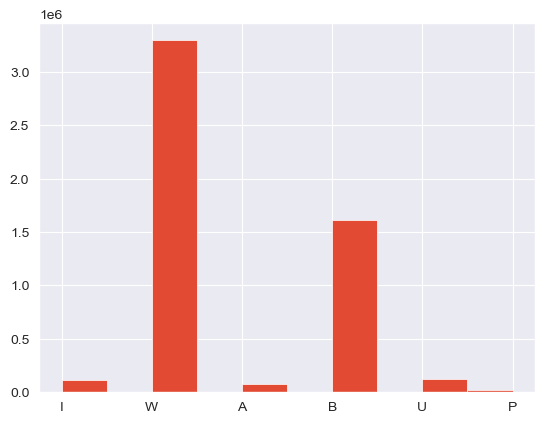

In [13]:
data_df["race_of_arrestee"].hist()

In [14]:
data_df[lambda x: (x.ethnicity_of_arrestee.isna()) & (x.race_of_arrestee == 'U')]

,segment_level,state_code,ori,incident_number,incident_date,arrestee_sequence_number,arrest_transaction_number,arrest_date,type_of_arrest,multiple_arrestee_segment_indicator,ucr_arrest_offense_code,type_weapon_involved1,automatic_weapon_indicator1,type_weapon_involved2,automatic_weapon_indicator2,age_of_arrestee,sex_of_arrestee,race_of_arrestee,ethnicity_of_arrestee,residence_status_of_arrestee,disposition_arrestee_under_18,db_id,is_groupb,city_submission
1142,6,50,AK0010500,PN-0XGWWVSCT,2024-08-30,1,113497002,2024-08-30,O,N,35A,1,NaN,NaN,NaN,21,M,U,NaN,NaN,NaN,2024_1143,0,NaN
1464,6,50,AK0011200,CE-4AOQU728N,2024-04-06,1,5295,2024-04-06,O,N,13B,1,NaN,NaN,NaN,19,M,U,NaN,NaN,NaN,2024_1465,0,NaN
1987,6,50,AK0011800,CE0 0FEU728N,2024-12-29,1,252,2024-12-29,T,N,13B,1,NaN,NaN,NaN,22,M,U,NaN,NaN,NaN,2024_1988,0,NaN
2271,6,50,AK0012300,5219Q088MRVS,2024-10-17,1,20263,2024-10-23,T,N,35A,1,NaN,NaN,NaN,15,F,U,NaN,NaN,R,2024_2272,0,NaN
2286,6,50,AK0012300,521TQ0WJ0RVS,2024-11-06,1,20268,2024-11-06,T,N,520,12,NaN,NaN,NaN,32,M,U,NaN,NaN,NaN,2024_2287,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2919262,7,47,WVWSP6600,NZ5OHCTD1AEM,2024-03-17,1,NaN,2024-03-17,O,NaN,90Z,1,NaN,NaN,NaN,31,M,U,NaN,NaN,NaN,2024_2919263,1,NaN
2919265,7,47,WVWSP6600,OV76 AEMQ-F3,2024-06-22,1,NaN,2024-06-22,O,NaN,90Z,1,NaN,NaN,NaN,46,F,U,NaN,R,NaN,2024_2919266,1,NaN
2919267,7,47,WVWSP6600,OZ770AEMQ-F3,2024-02-02,1,NaN,2024-02-02,O,NaN,90Z,1,NaN,NaN,NaN,34,M,U,NaN,NaN,NaN,2024_2919268,1,NaN
2919272,7,47,WVWSP9800,QT179YBRVSCT,2024-06-17,1,NaN,2024-06-17,O,NaN,90Z,14,NaN,NaN,NaN,35,M,U,NaN,NaN,NaN,2024_2919273,1,NaN


In [15]:
data_df["ethnicity_of_arrestee"] = data_df["ethnicity_of_arrestee"].fillna("U")
data_df["ethnicity_of_arrestee"].value_counts()

ethnicity_of_arrestee
N    3375500
H     980118
U     890349
Name: count, dtype: int64

<Axes: >

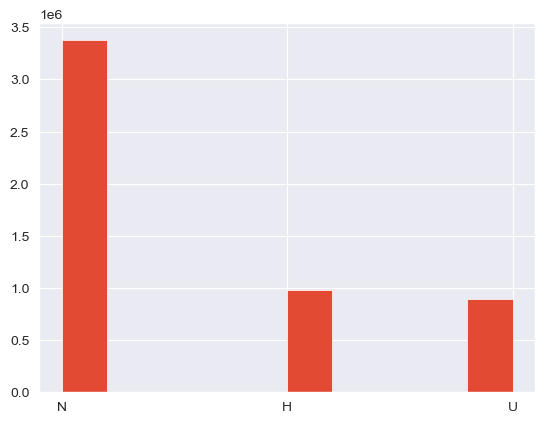

In [16]:
data_df["ethnicity_of_arrestee"].hist()

In [17]:
data_df = data_df.assign(
    race_ethnicity_arrestee = lambda x: 
            np.where(
                x.ethnicity_of_arrestee == 'H',
                x.ethnicity_of_arrestee,
                x.race_of_arrestee
            )
)

In [18]:
any(data_df["race_ethnicity_arrestee"].isna())

False

<Axes: >

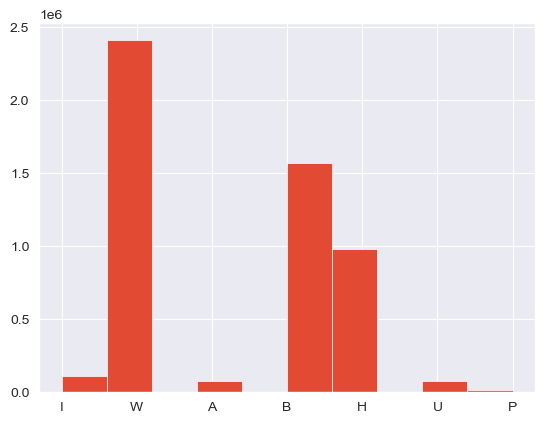

In [19]:
data_df["race_ethnicity_arrestee"].hist()

In [20]:
data_df["race_of_arrestee"].value_counts()

race_of_arrestee
W    3294667
B    1610312
U     127303
I     112663
A      80146
P      20876
Name: count, dtype: int64

In [21]:
data_df["race_ethnicity_arrestee"].value_counts()

race_ethnicity_arrestee
W    2412177
B    1570517
H     980118
I     108901
U      78253
A      77705
P      18296
Name: count, dtype: int64

In [22]:
data_df[lambda x: x.race_ethnicity_arrestee == "U"]["ethnicity_of_arrestee"].value_counts()

ethnicity_of_arrestee
U    56875
N    21378
Name: count, dtype: int64

In [23]:
(
    data_df
        [lambda x: (x.ethnicity_of_arrestee == 'U') & (x.race_of_arrestee == 'W')]
        .shape
)

(522451, 25)

In [24]:
(
    data_df
        [lambda x: (x.ethnicity_of_arrestee == 'U') & (x.race_of_arrestee == 'U')]
        .shape
)

(56875, 25)

### Distribution by UCR Arrest Offense Code

<Axes: xlabel='ucr_arrest_offense_code'>

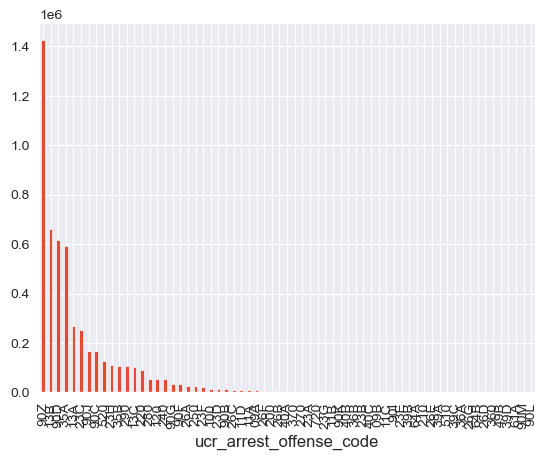

In [25]:
(
    data_df
        ["ucr_arrest_offense_code"]
        .value_counts()
        .sort_values(ascending=False)
        .plot(kind="bar")
)

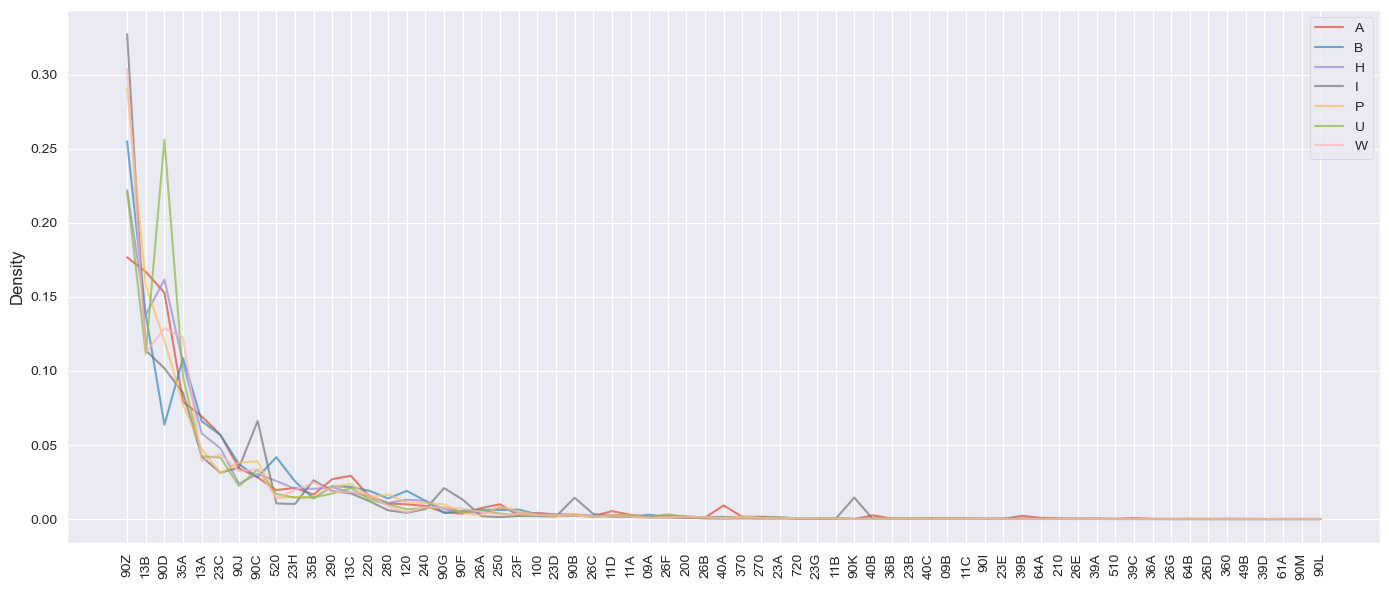

In [26]:
ordered_indices = (
    data_df["ucr_arrest_offense_code"]
    .value_counts()
    .sort_values(ascending=False)
    .index.tolist()
)

fig, ax = plt.subplots(figsize=(14, 6))
for race in sorted(data_df["race_ethnicity_arrestee"].unique()):
    subset = data_df[data_df["race_ethnicity_arrestee"] == race]
    counts = subset["ucr_arrest_offense_code"].value_counts(normalize=True).reindex(ordered_indices, fill_value=0)
    ax.plot(ordered_indices, counts.values, label=race, alpha=0.7)
ax.set_xticks(range(len(ordered_indices)))
ax.set_xticklabels(ordered_indices, rotation=90)
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.show()

**Observations:**
- U:
    - Density of 90D (drunken driving) is higher than all other races
    - Perhaps this makes sense from first principles

<Axes: xlabel='ucr_arrest_offense_code'>

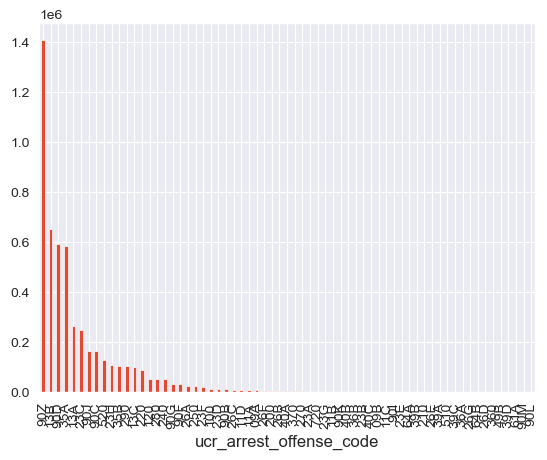

In [27]:
(
    data_df
        [lambda x: (x.race_ethnicity_arrestee != 'U')]
        ["ucr_arrest_offense_code"]
        .value_counts()
        .plot(kind="bar")
)

<Axes: xlabel='ucr_arrest_offense_code'>

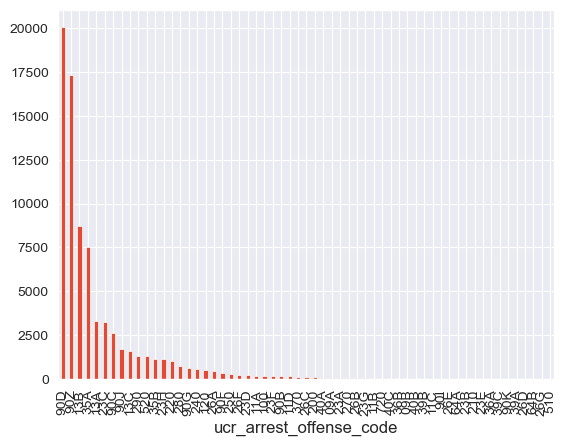

In [28]:
(
    data_df
        [lambda x: (x.race_ethnicity_arrestee == 'U')]
        ["ucr_arrest_offense_code"]
        .value_counts()
        .plot(kind="bar")
)

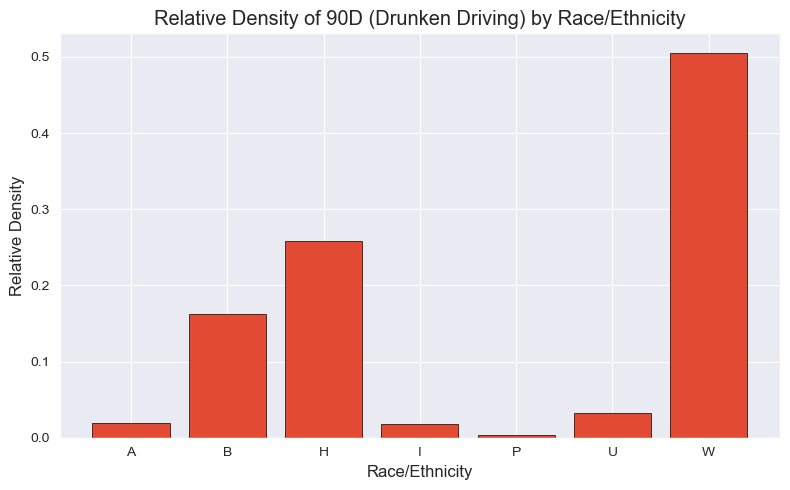

In [29]:
# Filter only 90D offenses
df_90d = data_df[data_df["ucr_arrest_offense_code"] == "90D"]

# Count by race for 90D, normalize to relative density
race_counts = (
    df_90d["race_ethnicity_arrestee"]
    .value_counts(normalize=True)
    .sort_index()
    .reset_index()
)
race_counts.columns = ["race_ethnicity", "relative_density"]

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(race_counts["race_ethnicity"], race_counts["relative_density"], edgecolor="black")
ax.set_xlabel("Race/Ethnicity")
ax.set_ylabel("Relative Density")
ax.set_title("Relative Density of 90D (Drunken Driving) by Race/Ethnicity")
plt.tight_layout()
plt.show()

### Distribution by States

In [30]:
state_code_dict = {
    1: "Alabama",
    2: "Arizona",
    3: "Arkansas",
    4: "California",
    5: "Colorado",
    6: "Connecticut",
    7: "Delaware",
    8: "District of Columbia",
    9: "Florida",
    10: "Georgia",
    11: "Idaho",
    12: "Illinois",
    13: "Indiana",
    14: "Iowa",
    15: "Kansas",
    16: "Kentucky",
    17: "Louisiana",
    18: "Maine",
    19: "Maryland",
    20: "Massachusetts",
    21: "Michigan",
    22: "Minnesota",
    23: "Mississippi",
    24: "Missouri",
    25: "Montana",
    26: "Nebraska",
    27: "Nevada",
    28: "New Hampshire",
    29: "New Jersey",
    30: "New Mexico",
    31: "New York",
    32: "North Carolina",
    33: "North Dakota",
    34: "Ohio",
    35: "Oklahoma",
    36: "Oregon",
    37: "Pennsylvania",
    38: "Rhode Island",
    39: "South Carolina",
    40: "South Dakota",
    41: "Tennessee",
    42: "Texas",
    43: "Utah",
    44: "Vermont",
    45: "Virginia",
    46: "Washington",
    47: "West Virginia",
    48: "Wisconsin",
    49: "Wyoming",
    50: "Alaska",
    51: "Hawaii",
    52: "Canal Zone",
    53: "Puerto Rico",
    54: "American Samoa",
    55: "Guam",
    62: "Virgin Islands"
}

In [31]:
data_df = data_df.assign(state_name = lambda x: x.state_code.map(state_code_dict))
data_df

,segment_level,state_code,ori,incident_number,incident_date,arrestee_sequence_number,arrest_transaction_number,arrest_date,type_of_arrest,multiple_arrestee_segment_indicator,ucr_arrest_offense_code,type_weapon_involved1,automatic_weapon_indicator1,type_weapon_involved2,automatic_weapon_indicator2,age_of_arrestee,sex_of_arrestee,race_of_arrestee,ethnicity_of_arrestee,residence_status_of_arrestee,disposition_arrestee_under_18,db_id,is_groupb,city_submission,race_ethnicity_arrestee,state_name
0,6,50,AK0010200,CE0BAA3C728N,2024-08-15,1,55086,2024-12-28,T,N,26A,1,NaN,NaN,NaN,26,M,I,N,R,NaN,2024_1,0,NaN,I,Alaska
1,6,50,AK0010200,CE0BAAB-728N,2024-08-15,1,54511,2024-08-15,O,N,13B,1,NaN,NaN,NaN,40,M,I,N,N,NaN,2024_2,0,NaN,I,Alaska
2,6,50,AK0010200,CE0BAAML728N,2024-08-13,1,56308,2025-02-20,T,N,520,1,NaN,NaN,NaN,30,M,I,N,N,NaN,2024_3,0,NaN,I,Alaska
3,6,50,AK0010200,CE0BAAMM728N,2024-08-13,1,54484,2024-08-13,O,N,13A,1,NaN,NaN,NaN,45,M,W,N,R,NaN,2024_4,0,NaN,W,Alaska
4,6,50,AK0010200,CE0BAAQC728N,2024-08-09,1,56142,2025-01-12,T,M,26A,1,NaN,NaN,NaN,26,M,A,N,R,NaN,2024_5,0,NaN,A,Alaska
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2929862,7,49,WYWHP0000,YX9B5HPU728N,2024-08-24,11,NaN,2024-08-24,O,NaN,90D,1,NaN,NaN,NaN,61,F,W,N,R,NaN,2024_2929863,1,NaN,W,Wyoming
2929864,7,49,WYWHP0000,YX9V5HPU728N,2024-08-21,17,NaN,2024-08-21,T,NaN,90Z,1,NaN,NaN,NaN,73,M,W,N,N,NaN,2024_2929865,1,NaN,W,Wyoming
2929865,7,49,WYWHP0000,Z52SCTD1AEM,2024-12-07,68,NaN,2024-12-07,T,NaN,90D,1,NaN,NaN,NaN,23,M,W,N,N,NaN,2024_2929866,1,NaN,W,Wyoming
2929866,7,49,WYWHP0000,Z5OSCTD1AEM,2024-12-15,60,NaN,2024-12-15,O,NaN,90Z,1,NaN,NaN,NaN,33,M,A,N,N,NaN,2024_2929867,1,NaN,A,Wyoming


<Axes: xlabel='state_name'>

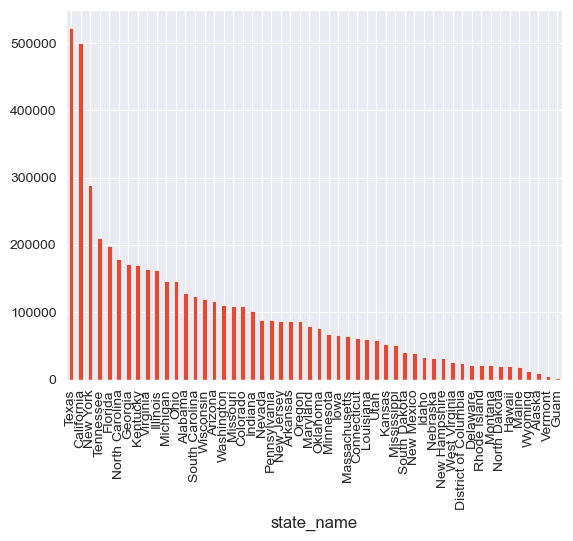

In [32]:
(
    data_df
        ["state_name"]
        .value_counts()
        .sort_values(ascending=False)
        .plot(kind="bar")
)

<Axes: xlabel='state_name'>

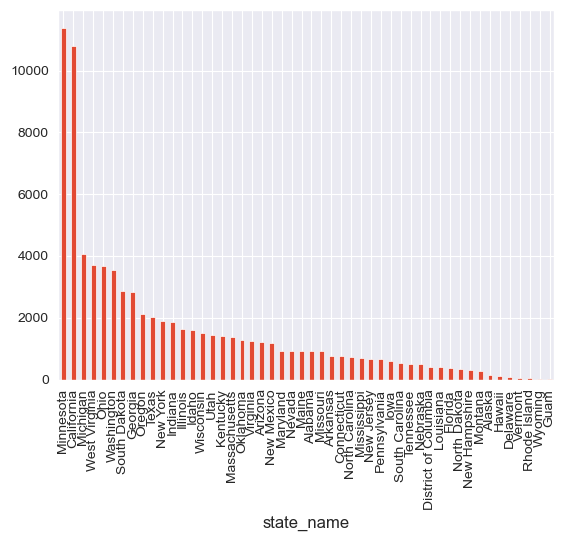

In [33]:
(
    data_df
        [lambda x: (x.race_ethnicity_arrestee == 'U')]
        ["state_name"]
        .value_counts()
        .sort_values(ascending=False)
        .plot(kind="bar")
)

#### Why Minnesota


<Axes: >

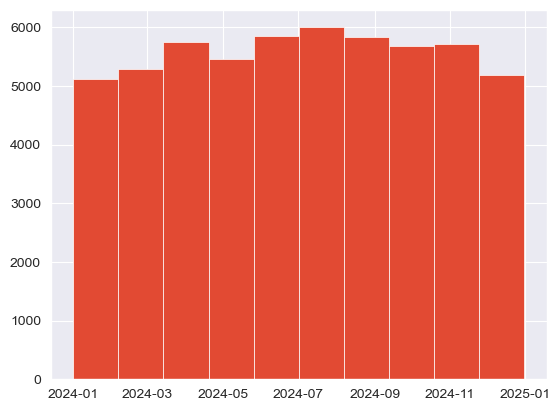

In [34]:
(
    data_df
        [lambda x: (x.race_ethnicity_arrestee != 'U') & (x.state_name == "Minnesota")]
        ["incident_date"]
        .hist()
)

<Axes: >

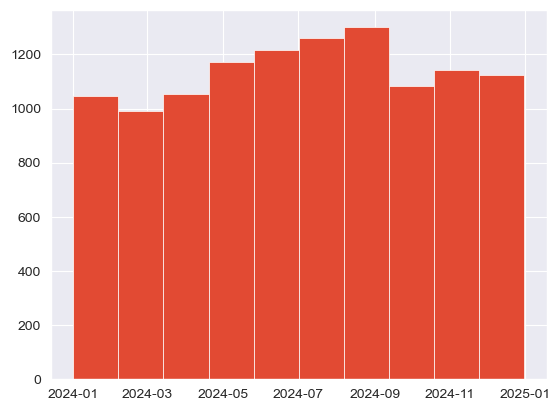

In [35]:
(
    data_df
        [lambda x: (x.race_ethnicity_arrestee == 'U') & (x.state_name == "Minnesota")]
        ["incident_date"]
        .hist()
)

<Axes: xlabel='ucr_arrest_offense_code'>

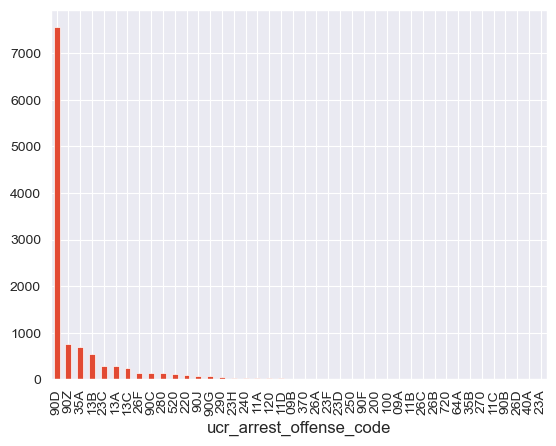

In [36]:
(
    data_df
        [lambda x: (x.race_ethnicity_arrestee == 'U') & (x.state_name == "Minnesota")]
        ["ucr_arrest_offense_code"]
        .value_counts()
        .plot(kind="bar")
)

<Axes: xlabel='ucr_arrest_offense_code'>

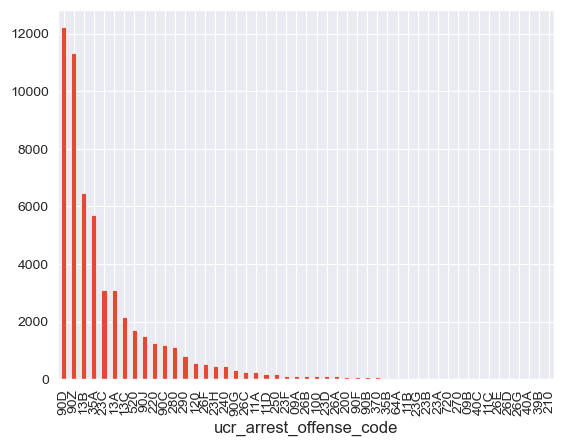

In [37]:
(
    data_df
        [lambda x: (x.race_ethnicity_arrestee != 'U') & (x.state_name == "Minnesota")]
        ["ucr_arrest_offense_code"]
        .value_counts()
        .plot(kind="bar")
)

## Temporal Data

TODO: 
- Look at the consecutive gaps between reports per agency; we care more about deviation from E[len(gap)]
- Conditioned on a report getting filed, then no missing reports for that day
- Can also look at deviation from E[# of reports on a given day]

In [38]:
data_df["ori"].nunique()

13046

In [39]:
data_df.head().T

,0,1,2,3,4
segment_level,6,6,6,6,6
state_code,50,50,50,50,50
ori,AK0010200,AK0010200,AK0010200,AK0010200,AK0010200
incident_number,CE0BAA3C728N,CE0BAAB-728N,CE0BAAML728N,CE0BAAMM728N,CE0BAAQC728N
incident_date,2024-08-15 00:00:00,2024-08-15 00:00:00,2024-08-13 00:00:00,2024-08-13 00:00:00,2024-08-09 00:00:00
arrestee_sequence_number,1,1,1,1,1
arrest_transaction_number,55086,54511,56308,54484,56142
arrest_date,2024-12-28 00:00:00,2024-08-15 00:00:00,2025-02-20 00:00:00,2024-08-13 00:00:00,2025-01-12 00:00:00
type_of_arrest,T,O,T,O,T
multiple_arrestee_segment_indicator,N,N,N,N,M


In [40]:
data_df = data_df.assign(
    month= lambda x: x.incident_date.dt.month,
    day= lambda x: x.incident_date.dt.day,
    day_of_week= lambda x: x.incident_date.dt.dayofweek
)

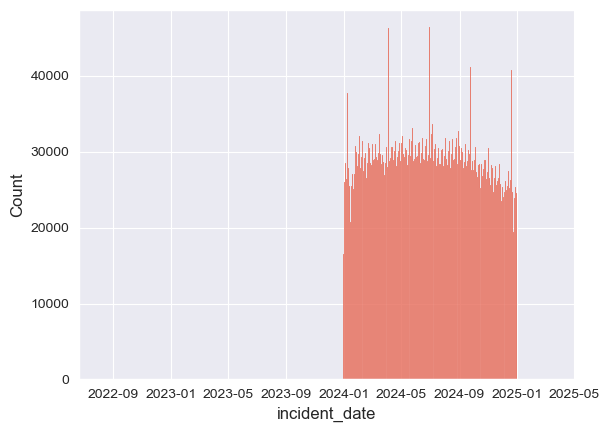

In [41]:
sns.histplot(data=data_df, x="incident_date")
plt.show()

In [42]:
(
    data_df
        [lambda x: ~x.incident_date.between(datetime(2024,1,1), datetime(2024,12,31), inclusive="both")]
        .sort_values(by="incident_date")
)

,segment_level,state_code,ori,incident_number,incident_date,arrestee_sequence_number,arrest_transaction_number,arrest_date,type_of_arrest,multiple_arrestee_segment_indicator,ucr_arrest_offense_code,type_weapon_involved1,automatic_weapon_indicator1,type_weapon_involved2,automatic_weapon_indicator2,age_of_arrestee,sex_of_arrestee,race_of_arrestee,ethnicity_of_arrestee,residence_status_of_arrestee,disposition_arrestee_under_18,db_id,is_groupb,city_submission,race_ethnicity_arrestee,state_name,month,day,day_of_week
1935661,7,34,OH0470300,2W2JPU72Z22O,2022-08-08,1,NaN,2022-08-08,T,NaN,90D,1,NaN,NaN,NaN,45,M,B,U,R,NaN,2024_1935662,1,NaN,B,Ohio,8,8,0
1212839,7,17,LA0440000,8T84RHPU728N,2023-05-18,1,NaN,2023-05-18,O,NaN,90Z,1,NaN,NaN,NaN,19,M,B,N,R,NaN,2024_1212840,1,NaN,B,Louisiana,5,18,3
1963008,7,34,OH0870100,Z8224IA6BF39,2023-09-02,2,NaN,2023-09-02,T,NaN,90G,1,NaN,NaN,NaN,19,M,B,U,U,NaN,2024_1963009,1,NaN,B,Ohio,9,2,5
1966832,7,34,OHCOP0000,P-30AE4P6SCT,2023-11-01,2,NaN,2023-11-01,T,NaN,90Z,1,NaN,NaN,NaN,36,F,W,U,R,NaN,2024_1966833,1,NaN,W,Ohio,11,1,2
631149,7,9,FL0080000,EL2IR-HEXCVS,2023-11-15,2,NaN,2023-11-15,O,NaN,90Z,1,NaN,NaN,NaN,48,F,W,U,U,NaN,2024_631150,1,NaN,W,Florida,11,15,2
638546,7,9,FL0130600,YZRW3A39G0AE,2025-01-01,3,NaN,2025-01-01,O,NaN,90Z,1,NaN,NaN,NaN,35,M,W,H,N,NaN,2024_638547,1,NaN,H,Florida,1,1,2
1933923,7,34,OH0430600,2W2ZPU7ZUN8R,2025-01-03,5,NaN,2025-01-03,T,NaN,90J,1,NaN,NaN,NaN,33,M,W,U,N,NaN,2024_1933924,1,NaN,W,Ohio,1,3,4
1933922,7,34,OH0430600,2W2ZPU7ZUN8R,2025-01-03,4,NaN,2025-01-03,T,NaN,90J,1,NaN,NaN,NaN,33,M,W,U,N,NaN,2024_1933923,1,NaN,W,Ohio,1,3,4
1637682,7,32,NC0430000,3A2-QVFG970I,2025-01-05,6,NaN,2025-01-05,T,NaN,90Z,1,NaN,NaN,NaN,35,F,W,N,R,NaN,2024_1637683,1,NaN,W,North Carolina,1,5,6
1637694,7,32,NC0430000,3A2-QVFG9G7I,2025-01-05,5,NaN,2025-01-05,T,NaN,90Z,1,NaN,NaN,NaN,60,F,W,N,R,NaN,2024_1637695,1,NaN,W,North Carolina,1,5,6


TODO: look into these examples above

In [43]:
data_df_filtered = (
    data_df
        [lambda x: x.incident_date.between(datetime(2024,1,1), datetime(2024,12,31), inclusive="both")]
        .sort_values(by="incident_date")
)

In [44]:
data_df_filtered

,segment_level,state_code,ori,incident_number,incident_date,arrestee_sequence_number,arrest_transaction_number,arrest_date,type_of_arrest,multiple_arrestee_segment_indicator,ucr_arrest_offense_code,type_weapon_involved1,automatic_weapon_indicator1,type_weapon_involved2,automatic_weapon_indicator2,age_of_arrestee,sex_of_arrestee,race_of_arrestee,ethnicity_of_arrestee,residence_status_of_arrestee,disposition_arrestee_under_18,db_id,is_groupb,city_submission,race_ethnicity_arrestee,state_name,month,day,day_of_week
917557,7,12,IL0169400,V-ZL6XAG0W5,2024-01-01,1,NaN,2024-01-01,O,NaN,90D,1,NaN,NaN,NaN,30,F,W,U,NaN,NaN,2024_917558,1,NaN,W,Illinois,1,1,0
2023725,6,27,NV0020100,O 0GJ4KOZTRX,2024-01-01,1,0,2024-01-01,T,N,13B,1,NaN,NaN,NaN,23,F,B,N,N,NaN,2024_2023726,0,NaN,B,Nevada,1,1,0
2023724,6,27,NV0020100,O 0GJ4KOZMRS,2024-01-01,1,7108985,2024-01-01,T,C,520,16,NaN,NaN,NaN,33,M,W,H,R,NaN,2024_2023725,0,NaN,H,Nevada,1,1,0
2023714,6,27,NV0020100,O 0GJ4KOPTRI,2024-01-01,1,8473138,2024-01-01,T,C,13B,1,NaN,NaN,NaN,22,F,W,H,R,NaN,2024_2023715,0,NaN,H,Nevada,1,1,0
2023713,6,27,NV0020100,O 0GJ4KOPLR1,2024-01-01,1,5020276,2024-01-01,T,N,35A,1,NaN,NaN,NaN,24,F,B,N,R,NaN,2024_2023714,0,NaN,B,Nevada,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1510501,6,21,MI4714700,350MQ523ZL12,2024-12-31,1,240002406617,2024-12-31,T,N,35A,1,NaN,NaN,NaN,40,M,W,U,NaN,NaN,2024_1510502,0,NaN,W,Michigan,12,31,1
1212924,6,15,KS0400100,CE- 0EMU728N,2024-12-31,1,3040A2500001,2024-12-31,O,N,13C,1,NaN,NaN,NaN,27,M,W,N,N,NaN,2024_1212925,0,NaN,W,Kansas,12,31,1
298685,6,4,CA0194200,V1ZTSZAG0W5,2024-12-31,1,241200021332,2024-12-31,O,C,240,1,NaN,NaN,NaN,40,F,W,U,NaN,NaN,2024_298686,0,NaN,W,California,12,31,1
211199,6,4,CA0040200,NZ-U7UI4KAEM,2024-12-31,1,24-009455R1,2024-12-31,O,N,13A,1,NaN,NaN,NaN,36,F,W,N,NaN,NaN,2024_211200,0,NaN,W,California,12,31,1


<Axes: >

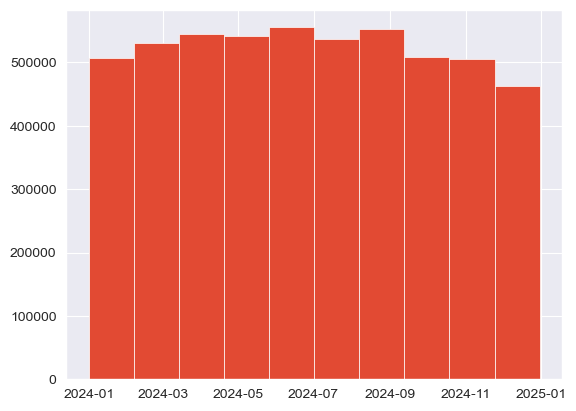

In [45]:
data_df_filtered["incident_date"].hist()

### Example ORI: AK0010200

In [46]:
df = data_df_filtered[lambda x: x.ori == 'AK0010200']
df

,segment_level,state_code,ori,incident_number,incident_date,arrestee_sequence_number,arrest_transaction_number,arrest_date,type_of_arrest,multiple_arrestee_segment_indicator,ucr_arrest_offense_code,type_weapon_involved1,automatic_weapon_indicator1,type_weapon_involved2,automatic_weapon_indicator2,age_of_arrestee,sex_of_arrestee,race_of_arrestee,ethnicity_of_arrestee,residence_status_of_arrestee,disposition_arrestee_under_18,db_id,is_groupb,city_submission,race_ethnicity_arrestee,state_name,month,day,day_of_week
133,7,50,AK0010200,P056PCTD1AEM,2024-01-01,1,NaN,2024-01-01,O,NaN,90D,1,NaN,NaN,NaN,34,F,W,N,R,NaN,2024_134,1,NaN,W,Alaska,1,1,0
134,7,50,AK0010200,P056ZCTD1AEM,2024-01-01,1,NaN,2024-01-01,O,NaN,90D,1,NaN,NaN,NaN,39,F,W,H,R,NaN,2024_135,1,NaN,H,Alaska,1,1,0
705,6,50,AK0010200,CE0BRVZC728N,2024-01-01,1,53553,2024-01-01,O,N,220,1,NaN,NaN,NaN,56,M,B,N,R,NaN,2024_706,0,NaN,B,Alaska,1,1,0
703,6,50,AK0010200,CE0BRVSR728N,2024-01-01,1,53550,2024-01-01,O,N,520,1,NaN,NaN,NaN,26,M,W,N,N,NaN,2024_704,0,NaN,W,Alaska,1,1,0
163,7,50,AK0010200,Y66B1HPU728N,2024-01-03,1,NaN,2024-01-03,O,NaN,90J,1,NaN,NaN,NaN,59,F,I,N,R,NaN,2024_164,1,NaN,I,Alaska,1,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
744,6,50,AK0010200,CE0B-Y3D728N,2024-12-29,1,55073,2024-12-31,O,N,13B,1,NaN,NaN,NaN,60,M,W,N,N,NaN,2024_745,0,NaN,W,Alaska,12,29,6
751,6,50,AK0010200,CE0B-YZM728N,2024-12-29,1,55064,2024-12-29,O,N,13B,1,NaN,NaN,NaN,34,F,I,N,R,NaN,2024_752,0,NaN,I,Alaska,12,29,6
745,6,50,AK0010200,CE0B-Y3L728N,2024-12-30,1,55067,2024-12-30,O,N,520,12,NaN,NaN,NaN,35,M,I,N,R,NaN,2024_746,0,NaN,I,Alaska,12,30,0
217,7,50,AK0010200,YB0GSHPU728N,2024-12-30,1,NaN,2024-12-30,O,NaN,90J,1,NaN,NaN,NaN,55,F,I,N,R,NaN,2024_218,1,NaN,I,Alaska,12,30,0


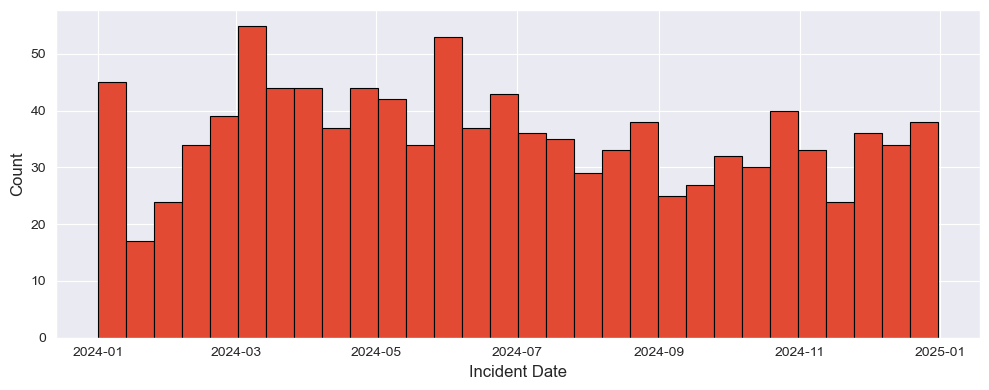

In [47]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df["incident_date"], bins=30, edgecolor="black", linewidth=0.8)
ax.set_xlabel("Incident Date")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

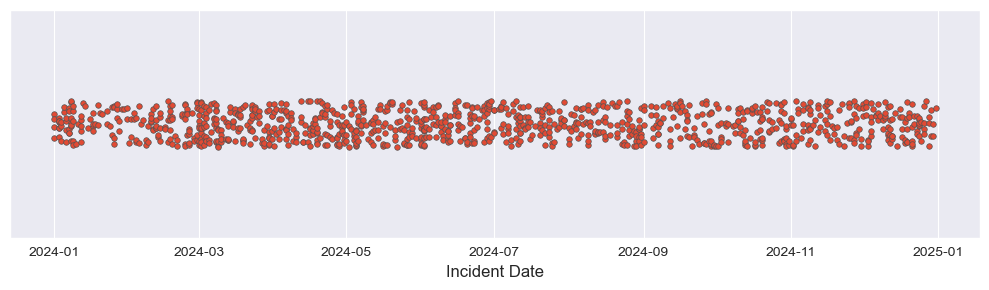

In [48]:
fig, ax = plt.subplots(figsize=(10, 3))
sns.stripplot(data=df, x="incident_date", ax=ax, size=4, linewidth=0.5, jitter=True)
ax.set_xlabel("Incident Date")
plt.tight_layout()
plt.show()

### Example ORI: IL0169400

In [49]:
df = data_df_filtered[lambda x: x.ori == 'IL0169400']
df.head()

,segment_level,state_code,ori,incident_number,incident_date,arrestee_sequence_number,arrest_transaction_number,arrest_date,type_of_arrest,multiple_arrestee_segment_indicator,ucr_arrest_offense_code,type_weapon_involved1,automatic_weapon_indicator1,type_weapon_involved2,automatic_weapon_indicator2,age_of_arrestee,sex_of_arrestee,race_of_arrestee,ethnicity_of_arrestee,residence_status_of_arrestee,disposition_arrestee_under_18,db_id,is_groupb,city_submission,race_ethnicity_arrestee,state_name,month,day,day_of_week
917557,7,12,IL0169400,V-ZL6XAG0W5,2024-01-01,1,NaN,2024-01-01,O,NaN,90D,1,NaN,NaN,NaN,30,F,W,U,NaN,NaN,2024_917558,1,NaN,W,Illinois,1,1,0
917313,7,12,IL0169400,EN54OCTD1AEM,2024-01-01,1,NaN,2024-01-01,O,NaN,90Z,1,NaN,NaN,NaN,31,M,W,U,NaN,NaN,2024_917314,1,NaN,W,Illinois,1,1,0
1047608,6,12,IL0169400,CE0BRV3U728N,2024-01-01,1,17576,2024-01-01,T,N,90D,1,NaN,NaN,NaN,30,M,W,H,N,NaN,2024_1047609,0,NaN,H,Illinois,1,1,0
1047609,6,12,IL0169400,CE0BRVTU728N,2024-01-02,1,17574,2024-01-02,O,N,35A,1,NaN,NaN,NaN,51,M,B,U,NaN,NaN,2024_1047610,0,NaN,B,Illinois,1,2,1
917540,7,12,IL0169400,V1-IYBRWPU72,2024-01-03,1,NaN,2024-01-03,O,NaN,90D,1,NaN,NaN,NaN,64,M,W,U,NaN,NaN,2024_917541,1,NaN,W,Illinois,1,3,2


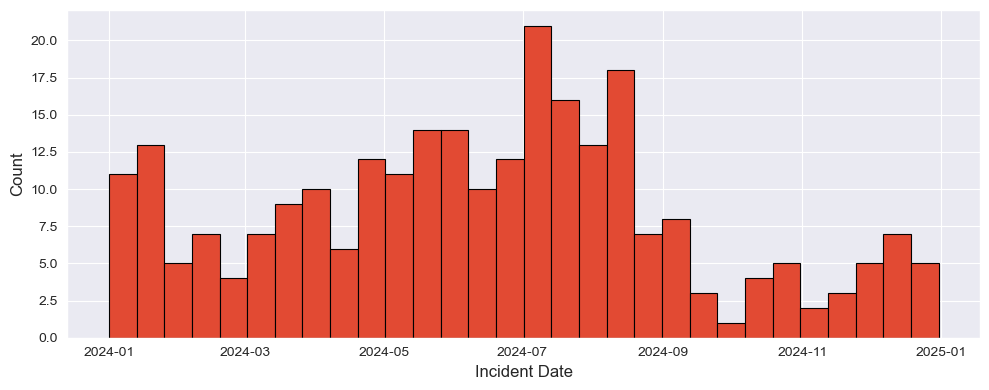

In [50]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df["incident_date"], bins=30, edgecolor="black", linewidth=0.8)
ax.set_xlabel("Incident Date")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

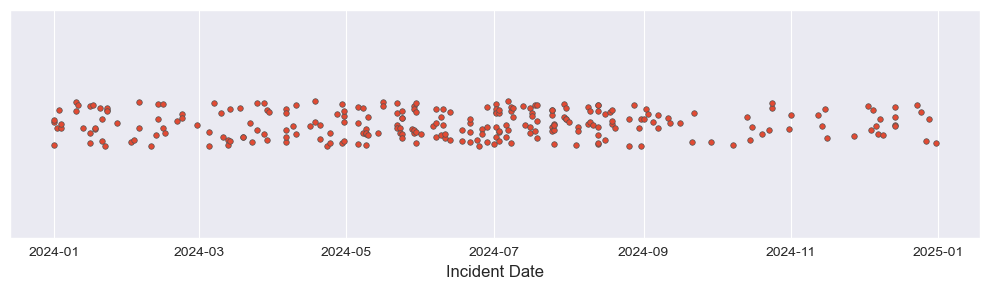

In [51]:
fig, ax = plt.subplots(figsize=(10, 3))
sns.stripplot(data=df, x="incident_date", ax=ax, size=4, linewidth=0.5, jitter=True)
ax.set_xlabel("Incident Date")
plt.tight_layout()
plt.show()

### Start of Year

In [52]:
num_unique_incident_dates_df = (
    data_df_filtered
        .groupby("ori")
        ["incident_date"]
        .nunique()
        .reset_index()
        .rename(columns={"incident_date" : "incident_date_count"})
        .sort_values(by="incident_date_count")
)
num_unique_incident_dates_df

,ori,incident_date_count
4243,LA0260600,1
2860,IL0191300,1
2856,IL0190600,1
7467,NH0102200,1
7451,NH0091200,1
...,...,...
9328,OR0340300,366
1666,CT0009300,366
12786,WIMPD0000,366
1699,CT0015100,366


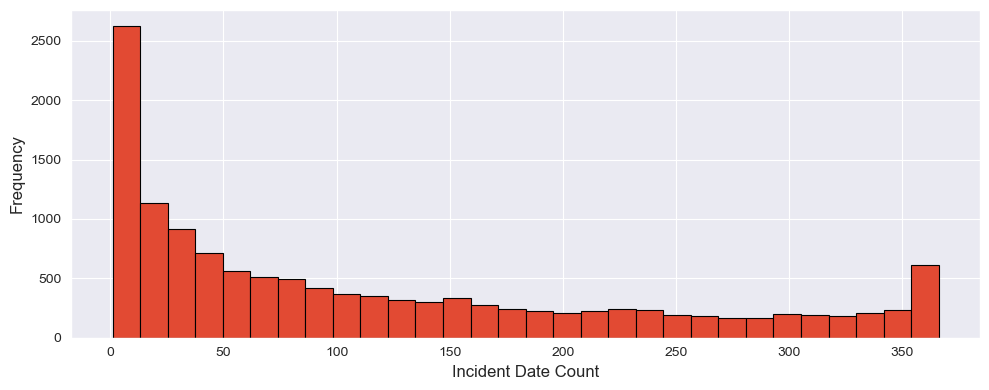

In [53]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(num_unique_incident_dates_df["incident_date_count"], bins=30, edgecolor="black", linewidth=0.8)
ax.set_xlabel("Incident Date Count")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

In [54]:
num_unique_incident_dates_df.describe()

,incident_date_count
count,13046.0000
mean,116.9828
std,113.8915
min,1.0000
25%,20.0000
50%,75.0000
75%,194.7500
max,366.0000


In [55]:
(
    data_df_filtered
        .assign(is_jan=lambda x: x.month == 1)
        .groupby("ori")["is_jan"]
        .sum()
        .reset_index(name="row_count")
        .sort_values("row_count")
        .set_index("ori")
        # .tail(20)  # just plot the 20 highest, for legibility
        # .plot(kind='bar')
)

,row_count
ori,
WADI06700,0
NB0830000,0
NB0790600,0
NB0790500,0
NB0730000,0
...,...
TXHPD0000,2676
TXSPD0000,2721
ILCPD0000,2733


In [56]:
(
    data_df_filtered
        .assign(is_jan=lambda x: x.month == 1)
        .groupby("ori")
        .agg(
            row_count=("is_jan", "sum"),
            unique_dates=("incident_date", "nunique")
        )
        .query("unique_dates >= 100")
        .sort_values("row_count")
        .drop(columns="unique_dates")
)


,row_count
ori,
IN0890100,0
CA0390200,0
CA0580000,0
PA0391300,0
IL0163500,0
...,...
TXHPD0000,2676
TXSPD0000,2721
ILCPD0000,2733


In [57]:
zero_jan_reports = (
    data_df_filtered
        .assign(is_jan=lambda x: x.month == 1)
        .groupby("ori")
        .agg(
            row_count=("is_jan", "sum"),
            unique_dates=("incident_date", "nunique")
        )
        .query("unique_dates >= 100")
        .sort_values("row_count")
        .drop(columns="unique_dates")
        .query("row_count == 0")
        .reset_index()
)


In [58]:
zero_jan_reports

,ori,row_count
0,IN0890100,0
1,CA0390200,0
2,CA0580000,0
3,PA0391300,0
4,IL0163500,0
5,PA0390100,0
6,PA0060300,0
7,IN0350000,0
8,PA0360500,0
9,IN0500200,0


### Example ORI: IN0890100

In [59]:
df = data_df_filtered[lambda x: x.ori == 'IN0890100']
df

,segment_level,state_code,ori,incident_number,incident_date,arrestee_sequence_number,arrest_transaction_number,arrest_date,type_of_arrest,multiple_arrestee_segment_indicator,ucr_arrest_offense_code,type_weapon_involved1,automatic_weapon_indicator1,type_weapon_involved2,automatic_weapon_indicator2,age_of_arrestee,sex_of_arrestee,race_of_arrestee,ethnicity_of_arrestee,residence_status_of_arrestee,disposition_arrestee_under_18,db_id,is_groupb,city_submission,race_ethnicity_arrestee,state_name,month,day,day_of_week
1021959,7,13,IN0890100,2K0HP2ROZ4JW,2024-04-01,1,NaN,2024-04-01,O,NaN,90D,1,NaN,NaN,NaN,67,M,B,N,R,NaN,2024_1021960,1,NaN,B,Indiana,4,1,0
1188787,6,13,IN0890100,RU2ZGU7VL71A,2024-04-01,1,240005677701,2024-04-01,O,N,13A,12,NaN,NaN,NaN,36,M,W,N,R,NaN,2024_1188788,0,NaN,W,Indiana,4,1,0
1188784,6,13,IN0890100,RU2ZGU7V941A,2024-04-01,1,240005677401,2024-04-01,O,N,35A,1,NaN,NaN,NaN,36,M,W,N,R,NaN,2024_1188785,0,NaN,W,Indiana,4,1,0
1021958,7,13,IN0890100,2K0HP2ROZ2JW,2024-04-02,1,NaN,2024-04-02,O,NaN,90Z,1,NaN,NaN,NaN,27,M,W,N,R,NaN,2024_1021959,1,NaN,W,Indiana,4,2,1
1021957,7,13,IN0890100,2K0HP2RO6YJW,2024-04-02,1,NaN,2024-04-02,O,NaN,90D,1,NaN,NaN,NaN,53,M,W,N,N,NaN,2024_1021958,1,NaN,W,Indiana,4,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1022053,7,13,IN0890100,2K0HP2ZZZ6JW,2024-12-30,1,NaN,2024-12-30,O,NaN,90Z,1,NaN,NaN,NaN,33,M,W,N,R,NaN,2024_1022054,1,NaN,W,Indiana,12,30,0
1022049,7,13,IN0890100,2K0HP2ZZSXJW,2024-12-30,1,NaN,2024-12-30,O,NaN,90Z,1,NaN,NaN,NaN,48,F,W,N,R,NaN,2024_1022050,1,NaN,W,Indiana,12,30,0
1022055,7,13,IN0890100,2K0HP2ZZZLJW,2024-12-31,1,NaN,2024-12-31,T,NaN,90Z,1,NaN,NaN,NaN,35,M,B,N,R,NaN,2024_1022056,1,NaN,B,Indiana,12,31,1
1022056,7,13,IN0890100,2K0HP2ZZZYJW,2024-12-31,1,NaN,2024-12-31,O,NaN,90C,1,NaN,NaN,NaN,37,M,W,N,R,NaN,2024_1022057,1,NaN,W,Indiana,12,31,1


In [60]:
df.shape

(687, 29)

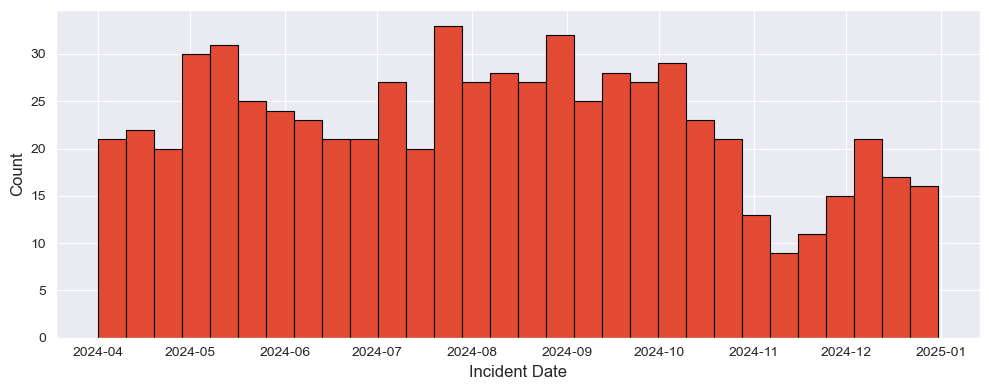

In [61]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df["incident_date"], bins=30, edgecolor="black", linewidth=0.8)
ax.set_xlabel("Incident Date")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

### Example ORI: CA0390200
This seems so wrong
https://www.lodi.gov/392/Statistics

In [62]:
df = data_df_filtered[lambda x: x.ori == 'CA0390200']
df

,segment_level,state_code,ori,incident_number,incident_date,arrestee_sequence_number,arrest_transaction_number,arrest_date,type_of_arrest,multiple_arrestee_segment_indicator,ucr_arrest_offense_code,type_weapon_involved1,automatic_weapon_indicator1,type_weapon_involved2,automatic_weapon_indicator2,age_of_arrestee,sex_of_arrestee,race_of_arrestee,ethnicity_of_arrestee,residence_status_of_arrestee,disposition_arrestee_under_18,db_id,is_groupb,city_submission,race_ethnicity_arrestee,state_name,month,day,day_of_week
462758,6,4,CA0390200,CV2ZGU7NJNBA,2024-08-01,1,240010377701,2024-08-01,O,N,13B,1,NaN,NaN,NaN,58,F,B,N,NaN,NaN,2024_462759,0,NaN,B,California,8,1,3
462756,6,4,CA0390200,CV2ZGU7NJG2A,2024-08-01,1,240010378201,2024-08-01,O,N,280,1,NaN,NaN,NaN,24,M,W,H,NaN,NaN,2024_462757,0,NaN,H,California,8,1,3
462755,6,4,CA0390200,CV2ZGU7NJG0A,2024-08-01,1,240010378101,2024-08-01,O,N,35B,1,NaN,NaN,NaN,41,M,W,N,NaN,NaN,2024_462756,0,NaN,W,California,8,1,3
462741,6,4,CA0390200,CV2ZGU7N6XJA,2024-08-01,1,240010422301,2024-09-15,T,N,290,1,NaN,NaN,NaN,58,M,W,N,NaN,NaN,2024_462742,0,NaN,W,California,8,1,3
385083,7,4,CA0390200,2K0HQUHOZXJW,2024-08-01,1,NaN,2024-08-01,O,NaN,90C,1,NaN,NaN,NaN,55,F,W,N,R,NaN,2024_385084,1,NaN,W,California,8,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
385050,7,4,CA0390200,2K0HQU82SCJW,2024-12-30,1,NaN,2024-12-30,O,NaN,90Z,1,NaN,NaN,NaN,27,M,W,H,U,NaN,2024_385051,1,NaN,H,California,12,30,0
385053,7,4,CA0390200,2K0HQU82Z7JW,2024-12-30,1,NaN,2024-12-30,T,NaN,90Z,1,NaN,NaN,NaN,27,M,W,U,N,NaN,2024_385054,1,NaN,W,California,12,30,0
462959,6,4,CA0390200,CV2ZGU7ULG A,2024-12-31,2,240010508002,2024-12-31,O,N,290,1,NaN,NaN,NaN,31,F,U,U,NaN,NaN,2024_462960,0,NaN,U,California,12,31,1
385054,7,4,CA0390200,2K0HQU82ZYJW,2024-12-31,1,NaN,2024-12-31,O,NaN,90D,1,NaN,NaN,NaN,31,M,W,H,N,NaN,2024_385055,1,NaN,H,California,12,31,1


In [63]:
df.shape

(699, 29)

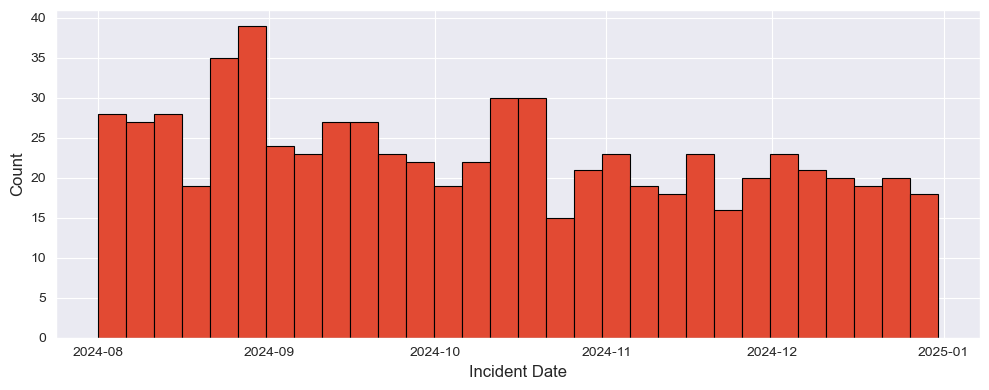

In [64]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df["incident_date"], bins=30, edgecolor="black", linewidth=0.8)
ax.set_xlabel("Incident Date")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

### Graphing for all 34 ORIs

In [65]:
to_graph_oris = zero_jan_reports["ori"].to_list()

In [66]:
from matplotlib.backends.backend_pdf import PdfPages

output_path = "all_jan_incident_histograms.pdf"

with PdfPages(output_path) as pdf:
    for ori in to_graph_oris:
        df = data_df_filtered.loc[lambda x: x.ori == ori]
        fig, ax = plt.subplots(figsize=(11, 6))
        ax.hist(df["incident_date"], bins=30, edgecolor="black", linewidth=0.8)
        ax.set_title(f"Incident Date Distribution — ORI: {ori} - Len: {len(df)}")
        ax.set_xlabel("Incident Date")
        ax.set_ylabel("Count")
        plt.tight_layout()
        pdf.savefig(fig)
        plt.close(fig)

print(f"Saved to {output_path}")

Saved to all_jan_incident_histograms.pdf


### Example ORI: CA0194200
Los Angeles Police Department

In [67]:
df = data_df_filtered[lambda x: x.ori == 'CA0194200']
df

,segment_level,state_code,ori,incident_number,incident_date,arrestee_sequence_number,arrest_transaction_number,arrest_date,type_of_arrest,multiple_arrestee_segment_indicator,ucr_arrest_offense_code,type_weapon_involved1,automatic_weapon_indicator1,type_weapon_involved2,automatic_weapon_indicator2,age_of_arrestee,sex_of_arrestee,race_of_arrestee,ethnicity_of_arrestee,residence_status_of_arrestee,disposition_arrestee_under_18,db_id,is_groupb,city_submission,race_ethnicity_arrestee,state_name,month,day,day_of_week
288619,6,4,CA0194200,CE0BRV5-728N,2024-03-07,1,240300000107,2024-03-07,O,N,23C,1,NaN,NaN,NaN,30,M,B,U,NaN,NaN,2024_288620,0,NaN,B,California,3,7,3
288620,6,4,CA0194200,CE0BRV5M728N,2024-03-07,1,240300000103,2024-03-07,O,C,35A,1,NaN,NaN,NaN,51,M,W,U,NaN,NaN,2024_288621,0,NaN,W,California,3,7,3
288624,6,4,CA0194200,CE0BRVRD728N,2024-03-07,1,240300000112,2024-03-07,O,N,23C,1,NaN,NaN,NaN,33,M,B,U,NaN,NaN,2024_288625,0,NaN,B,California,3,7,3
288623,6,4,CA0194200,CE0BRVR9728N,2024-03-07,1,240300000110,2024-03-07,O,N,23C,1,NaN,NaN,NaN,40,M,B,U,NaN,NaN,2024_288624,0,NaN,B,California,3,7,3
288622,6,4,CA0194200,CE0BRVQ9728N,2024-03-07,1,240300000109,2024-03-07,O,N,23C,1,NaN,NaN,NaN,31,F,W,U,NaN,NaN,2024_288623,0,NaN,W,California,3,7,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298713,6,4,CA0194200,V1ZTZI6G0W5,2024-12-31,1,241200021366,2024-12-31,O,N,13A,1,NaN,NaN,NaN,54,F,A,U,NaN,NaN,2024_298714,0,NaN,A,California,12,31,1
298712,6,4,CA0194200,V1ZTZ-FG0W5,2024-12-31,1,241200021361,2024-12-31,O,N,35A,1,NaN,NaN,NaN,37,M,B,U,NaN,NaN,2024_298713,0,NaN,B,California,12,31,1
298683,6,4,CA0194200,V1ZTSXYG0W5,2024-12-31,1,241200021324,2024-12-31,O,N,13B,1,NaN,NaN,NaN,62,M,B,U,NaN,NaN,2024_298684,0,NaN,B,California,12,31,1
298681,6,4,CA0194200,V1ZTSX G0W5,2024-12-31,1,241200021323,2024-12-31,O,N,13A,1,NaN,NaN,NaN,33,M,B,U,NaN,NaN,2024_298682,0,NaN,B,California,12,31,1


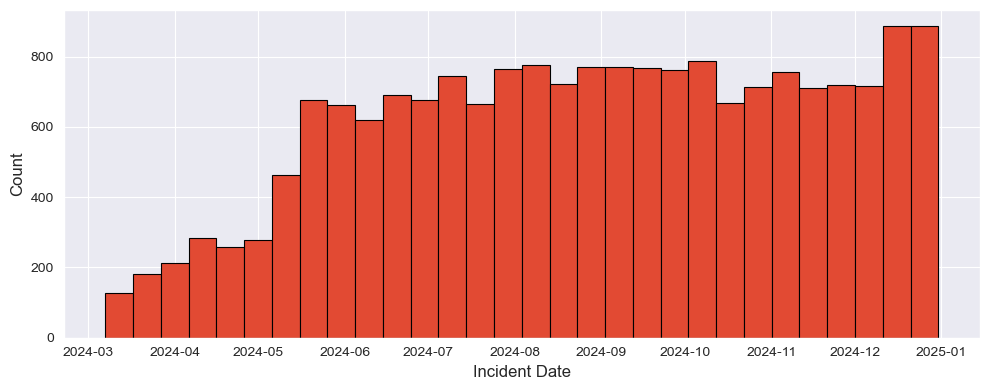

In [68]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df["incident_date"], bins=30, edgecolor="black", linewidth=0.8)
ax.set_xlabel("Incident Date")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

### Empty for Each Month

In [69]:
zero_month_reports_list = []

for i in range(1, 13):
    temp = (
        data_df_filtered
            .assign(is_specific_month=lambda x: x.month == i)
            .groupby("ori")
            .agg(
                row_count=("is_specific_month", "sum"),
                unique_dates=("incident_date", "nunique")
            )
            .query("unique_dates >= 100")
            .sort_values("row_count")
            .drop(columns="unique_dates")
            .query("row_count == 0")
            .reset_index()
    )
    zero_month_reports_list.append(temp)

zero_month_reports = pd.concat(zero_month_reports_list).drop_duplicates()
for t in zero_jan_reports:
    del t
gc.collect()


163815

In [70]:
zero_month_reports.reset_index(drop=True, inplace=True)
zero_month_reports.shape

(219, 2)

In [71]:
to_graph_oris = zero_month_reports["ori"].to_list()

In [72]:
from matplotlib.backends.backend_pdf import PdfPages

output_path = "all_incident_histograms.pdf"

with PdfPages(output_path) as pdf:
    for ori in to_graph_oris:
        df = data_df_filtered.loc[lambda x: x.ori == ori]
        fig, ax = plt.subplots(figsize=(11, 6))
        ax.hist(df["incident_date"], bins=30, edgecolor="black", linewidth=0.8)
        ax.set_title(f"Incident Date Distribution — ORI: {ori} - Len: {len(df)}")
        ax.set_xlabel("Incident Date")
        ax.set_ylabel("Count")
        plt.tight_layout()
        pdf.savefig(fig)
        plt.close(fig)

print(f"Saved to {output_path}")

Saved to all_incident_histograms.pdf


In [73]:
zero_month_reports["ori"]

0      IN0890100
1      CA0390200
2      CA0580000
3      PA0391300
4      IL0163500
5      PA0390100
6      PA0060300
7      IN0350000
8      PA0360500
9      IN0500200
10     UT0185200
11     AL0390000
12     AL0390100
13     OR0030600
14     TX0840100
15     CA0194200
16     GA0650000
17     NY0515500
18     FL0501700
19     CA0151000
20     FL0560000
21     FL0560100
22     FL0560200
23     NJ0122500
24     NY0146700
25     NY0145100
26     PA0220400
27     CA0196500
28     IL0169X00
29     NJ0091000
30     WADI06800
31     TX1460100
32     CA0489965
33     IL0490000
34     NH0050000
35     MS0440000
36     NY0060100
37     MS0180200
38     IN0660000
39     NJ0130300
40     MA0144500
41     WA0311900
42     IN0330200
43     WI0120100
44     MTDI00000
45     IL0491300
46     GA1590100
47     MI6160400
48     MA0050300
49     IN0750000
50     WI0490200
51     MI6116100
52     FL0060300
53     MI2312300
54     MI6160300
55     MS0530000
56     MTDI06200
57     MI6162500
58     GA15400

## Incident Number

In [74]:
data_df_filtered["incident_number"].value_counts().reset_index()["count"].sort_values().value_counts()

count
1      2934785
2       327361
3       115785
4        59525
5        35760
6        23201
7        15908
8        11261
9         7921
10        5664
11        4215
12        3410
13        2622
14        2170
15        1789
16        1409
17        1261
18         999
19         846
20         777
21         601
22         525
23         439
24         368
25         361
26         320
27         274
28         235
29         185
30         159
31         158
32         125
33         104
34         101
35          98
36          70
37          66
38          60
42          57
39          52
40          41
41          38
43          27
44          24
45          22
46          19
47          19
49          17
48          16
50          14
51          14
55          11
68          11
57          10
53           8
71           8
54           7
59           7
69           7
70           7
83           7
61           6
64           6
76           6
81           6
84           6
91  

In [75]:
data_df_filtered["incident_number"].value_counts().head(10)

incident_number
CE-1XZ8U728N    152
AF-LFRIOJ4KO    149
CE-4XZ8U728N    143
CE-QXZ8U728N    142
AF-L1RIOJ4KO    142
AF-LPRIOJ4KO    140
AF-QSRIOJ4KO    140
AF-RGRIOJ4KO    139
AF-QTRIOJ4KO    138
CE-DXZ8U728N    135
Name: count, dtype: int64

### CE-1XZ8U728N

In [76]:
data_df_filtered[lambda x: x.incident_number == 'CE-1XZ8U728N'].head()

,segment_level,state_code,ori,incident_number,incident_date,arrestee_sequence_number,arrest_transaction_number,arrest_date,type_of_arrest,multiple_arrestee_segment_indicator,ucr_arrest_offense_code,type_weapon_involved1,automatic_weapon_indicator1,type_weapon_involved2,automatic_weapon_indicator2,age_of_arrestee,sex_of_arrestee,race_of_arrestee,ethnicity_of_arrestee,residence_status_of_arrestee,disposition_arrestee_under_18,db_id,is_groupb,city_submission,race_ethnicity_arrestee,state_name,month,day,day_of_week
1741496,7,28,NH0086400,CE-1XZ8U728N,2024-01-01,1,NaN,2024-01-01,O,NaN,90Z,1,NaN,NaN,NaN,38,M,W,N,N,NaN,2024_1741497,1,NaN,W,New Hampshire,1,1,0
1736745,7,28,NH0072400,CE-1XZ8U728N,2024-01-01,1,NaN,2024-01-01,T,NaN,90Z,1,NaN,NaN,NaN,44,M,W,N,R,NaN,2024_1736746,1,NaN,W,New Hampshire,1,1,0
1739784,7,28,NH0083000,CE-1XZ8U728N,2024-01-01,1,NaN,2024-01-01,O,NaN,90D,1,NaN,NaN,NaN,56,F,W,N,N,NaN,2024_1739785,1,NaN,W,New Hampshire,1,1,0
1737876,7,28,NH0080000,CE-1XZ8U728N,2024-01-01,1,NaN,2024-01-01,T,NaN,90Z,1,NaN,NaN,NaN,38,M,W,N,N,NaN,2024_1737877,1,NaN,W,New Hampshire,1,1,0
1738331,7,28,NH0080600,CE-1XZ8U728N,2024-01-01,1,NaN,2024-01-01,O,NaN,90Z,1,NaN,NaN,NaN,19,M,W,N,N,NaN,2024_1738332,1,NaN,W,New Hampshire,1,1,0


In [77]:
data_df_filtered[lambda x: x.incident_number == 'CE-1XZ8U728N']["ori"].nunique()

149

### Num Unique (ORI, Incident #) pairs

In [78]:
data_df_filtered[["ori", "incident_number"]].value_counts().head(10)

ori        incident_number
CA0199700  CE0ASCPU728N       83
TX2270500  CE0QRYM9728N       78
OR020SP00  Z-2PRVPC9J I       57
TX2270500  CE0QRE5V728N       56
CA0309700  9H-QHPPDPCY7       47
NY0303000  WK0ZL716NYQS       45
WI0050200  7DTQGR3T90QH       42
OH0252700  JZ06B7KHPUR3       36
MA0082200  9H-WWSEDB IY       35
CA0120800  0G2ZGUF 7KF6       30
Name: count, dtype: int64

### CE0ASCPU728N

https://en.wikipedia.org/wiki/2024_University_of_California,_Los_Angeles_pro-Palestinian_campus_occupation

In [79]:
data_df_filtered[lambda x: (x.ori == "CA0199700") & (x.incident_number == "CE0ASCPU728N")]

,segment_level,state_code,ori,incident_number,incident_date,arrestee_sequence_number,arrest_transaction_number,arrest_date,type_of_arrest,multiple_arrestee_segment_indicator,ucr_arrest_offense_code,type_weapon_involved1,automatic_weapon_indicator1,type_weapon_involved2,automatic_weapon_indicator2,age_of_arrestee,sex_of_arrestee,race_of_arrestee,ethnicity_of_arrestee,residence_status_of_arrestee,disposition_arrestee_under_18,db_id,is_groupb,city_submission,race_ethnicity_arrestee,state_name,month,day,day_of_week
310691,6,4,CA0199700,CE0ASCPU728N,2024-05-02,1,12420,2024-05-02,O,N,90B,1,NaN,NaN,NaN,32,M,W,N,U,NaN,2024_310692,0,NaN,W,California,5,2,3
310692,6,4,CA0199700,CE0ASCPU728N,2024-05-02,2,12434,2024-05-02,O,N,90B,1,NaN,NaN,NaN,27,M,W,N,U,NaN,2024_310693,0,NaN,W,California,5,2,3
310693,6,4,CA0199700,CE0ASCPU728N,2024-05-02,4,12413,2024-05-02,O,N,90B,1,NaN,NaN,NaN,23,F,W,N,N,NaN,2024_310694,0,NaN,W,California,5,2,3
310694,6,4,CA0199700,CE0ASCPU728N,2024-05-02,5,12441,2024-05-02,O,N,90B,1,NaN,NaN,NaN,21,M,W,N,U,NaN,2024_310695,0,NaN,W,California,5,2,3
310695,6,4,CA0199700,CE0ASCPU728N,2024-05-02,6,12440,2024-05-02,O,N,90B,1,NaN,NaN,NaN,19,F,U,N,U,NaN,2024_310696,0,NaN,U,California,5,2,3
310696,6,4,CA0199700,CE0ASCPU728N,2024-05-02,7,12446,2024-05-02,O,N,90B,1,NaN,NaN,NaN,28,F,B,N,U,NaN,2024_310697,0,NaN,B,California,5,2,3
310699,6,4,CA0199700,CE0ASCPU728N,2024-05-02,12,12432,2024-05-02,O,N,90B,1,NaN,NaN,NaN,26,F,U,N,N,NaN,2024_310700,0,NaN,U,California,5,2,3
310700,6,4,CA0199700,CE0ASCPU728N,2024-05-02,13,12428,2024-05-02,O,N,90B,1,NaN,NaN,NaN,41,M,W,N,U,NaN,2024_310701,0,NaN,W,California,5,2,3
310697,6,4,CA0199700,CE0ASCPU728N,2024-05-02,10,12421,2024-05-02,O,N,90B,1,NaN,NaN,NaN,19,F,W,N,U,NaN,2024_310698,0,NaN,W,California,5,2,3
310698,6,4,CA0199700,CE0ASCPU728N,2024-05-02,11,12472,2024-05-02,O,N,90B,1,NaN,NaN,NaN,30,M,W,N,U,NaN,2024_310699,0,NaN,W,California,5,2,3


In [80]:
data_df_filtered[lambda x: (x.ori == "CA0199700") & (x.incident_number == "CE0ASCPU728N") 
                            & (x.race_of_arrestee == 'U') & (x.ethnicity_of_arrestee == 'U')]

,segment_level,state_code,ori,incident_number,incident_date,arrestee_sequence_number,arrest_transaction_number,arrest_date,type_of_arrest,multiple_arrestee_segment_indicator,ucr_arrest_offense_code,type_weapon_involved1,automatic_weapon_indicator1,type_weapon_involved2,automatic_weapon_indicator2,age_of_arrestee,sex_of_arrestee,race_of_arrestee,ethnicity_of_arrestee,residence_status_of_arrestee,disposition_arrestee_under_18,db_id,is_groupb,city_submission,race_ethnicity_arrestee,state_name,month,day,day_of_week


In [81]:
data_df_filtered[lambda x: (x.ori == "CA0199700") & (x.incident_number == "CE0ASCPU728N") 
                            & (x.race_of_arrestee == 'U') & (x.ethnicity_of_arrestee == 'N')]

,segment_level,state_code,ori,incident_number,incident_date,arrestee_sequence_number,arrest_transaction_number,arrest_date,type_of_arrest,multiple_arrestee_segment_indicator,ucr_arrest_offense_code,type_weapon_involved1,automatic_weapon_indicator1,type_weapon_involved2,automatic_weapon_indicator2,age_of_arrestee,sex_of_arrestee,race_of_arrestee,ethnicity_of_arrestee,residence_status_of_arrestee,disposition_arrestee_under_18,db_id,is_groupb,city_submission,race_ethnicity_arrestee,state_name,month,day,day_of_week
310695,6,4,CA0199700,CE0ASCPU728N,2024-05-02,6,12440,2024-05-02,O,N,90B,1,NaN,NaN,NaN,19,F,U,N,U,NaN,2024_310696,0,NaN,U,California,5,2,3
310699,6,4,CA0199700,CE0ASCPU728N,2024-05-02,12,12432,2024-05-02,O,N,90B,1,NaN,NaN,NaN,26,F,U,N,N,NaN,2024_310700,0,NaN,U,California,5,2,3
310705,6,4,CA0199700,CE0ASCPU728N,2024-05-02,18,12424,2024-05-02,O,N,90B,1,NaN,NaN,NaN,20,F,U,N,U,NaN,2024_310706,0,NaN,U,California,5,2,3
310708,6,4,CA0199700,CE0ASCPU728N,2024-05-02,23,12429,2024-05-02,O,N,90B,1,NaN,NaN,NaN,28,F,U,N,U,NaN,2024_310709,0,NaN,U,California,5,2,3
310704,6,4,CA0199700,CE0ASCPU728N,2024-05-02,17,12430,2024-05-02,O,N,90B,1,NaN,NaN,NaN,25,M,U,N,U,NaN,2024_310705,0,NaN,U,California,5,2,3
310702,6,4,CA0199700,CE0ASCPU728N,2024-05-02,15,12439,2024-05-02,O,N,90B,1,NaN,NaN,NaN,28,F,U,N,U,NaN,2024_310703,0,NaN,U,California,5,2,3
310721,6,4,CA0199700,CE0ASCPU728N,2024-05-02,43,12521,2024-05-02,O,N,90B,1,NaN,NaN,NaN,20,M,U,N,N,NaN,2024_310722,0,NaN,U,California,5,2,3
310732,6,4,CA0199700,CE0ASCPU728N,2024-05-02,54,12536,2024-05-02,O,N,90B,1,NaN,NaN,NaN,30,M,U,N,U,NaN,2024_310733,0,NaN,U,California,5,2,3
310759,6,4,CA0199700,CE0ASCPU728N,2024-05-02,83,12571,2024-05-02,O,N,90B,1,NaN,NaN,NaN,26,F,U,N,U,NaN,2024_310760,0,NaN,U,California,5,2,3
310760,6,4,CA0199700,CE0ASCPU728N,2024-05-02,84,12570,2024-05-02,O,N,90B,1,NaN,NaN,NaN,21,M,U,N,U,NaN,2024_310761,0,NaN,U,California,5,2,3
